## Импорт библиотек

In [33]:
import json
import phik
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

RANDOM_SEED = 42

## Дополнительный EDA

In [26]:
df= pd.read_csv("dataset/processed/atm_train_extended.csv")
df.head()

,id,atm_group,address,address_rus,lat,long,target,religious_buildings_100,food_drink_100,education_100,...,parking_count,parking_types,parking_distance,metro_count,metro_distance,bus_tram_count,bus_distance,city,region,is_urban
0,4510.0,496.5,PER. BAZARNY 4 SPASSK-DALNY,"Базарный переулок, 4, Спасск-Дальний, городско...",44.597339,132.816714,0.039191,0,0,0,...,3,"[""street_side"", ""parking""]",30.854156,0,0.0,4,207.224342,Спасск-Дальний,Приморский край,1
1,1591.0,1942.0,16A BEREJKOVSK NAB MOSCOW,"Бережковская набережная, 16А, Москва, Москва, ...",55.737836,37.562604,0.080034,0,1,0,...,0,empty,0.000000,0,0.0,9,136.903404,Москва,Москва,1
2,440.0,1942.0,113 MIRA AV. TOGLIATTI,"улица Мира, 113, Тольятти, городской округ Тол...",53.510690,49.444378,-0.082956,0,0,0,...,0,empty,0.000000,0,0.0,10,89.189146,городской округ Тольятти,Самарская область,1
3,556.0,1942.0,133A MOZHAYSKOE H/W. MOSCOW,"Можайское шоссе, 133А, Одинцово, Московская об...",55.684412,37.296119,0.061517,0,1,0,...,2,"[""surface""]",51.235761,0,0.0,10,51.497733,Одинцово,Московская область,1
4,568.0,1942.0,63A IZMAYLOVSKIY AV. MOSCOW,"Измайловский бульвар, 63А, Москва, Центральный...",55.785296,37.852078,0.008276,0,1,0,...,8,"[""multi-storey"", ""surface"", ""street_side""]",19.368039,0,0.0,5,249.717664,Балашиха,Московская область,1


### Трансформируем колонку `parking_types`

`parking_types` содержит json-список с типами парковок в округе. Создадим отдельный признак для каждого типа.

In [27]:
parkings = set()
for index, col in df.iterrows():
    if col["parking_types"] == "empty":
        continue
    parkings_lst = json.loads(col["parking_types"])
    for p in parkings_lst:
        parkings.add(p)
print(parkings)

{'yes', 'underground', 'multi-storey', 'street_side', 'shoulder', 'surface', 'garage', 'carports', 'parking', 'rooftop', 'sheds', 'lane', 'garage_boxes'}


In [28]:
for parking in parkings:
    df[parking] = 0

for index, col in df.iterrows():
    if col["parking_types"] == "empty":
        continue
    parkings_lst = json.loads(col["parking_types"])
    for p in parkings_lst:
        df.at[index, p] += 1
        
df = df.drop(columns=['parking_types'])

### Выберем наиболее значимые признаки

В изначальном датасете содержиться 83 (без учета разделенных `parking_types`) признака. По прошлому EDA - большинство из этих признаков имеют крайне малую корреляцию с целевой переменной.

Отберем признаки на основе порогового значения корреляции Спирмана:

In [29]:
CORR_THRESHOLD = 0.08

corr = df.corr(method="spearman", numeric_only=True)
target_corr = corr["target"].abs().sort_values(ascending=False)
target_corr = target_corr.drop(labels=["target"], errors="ignore")
filtered = target_corr[target_corr > CORR_THRESHOLD]
print(filtered)

atm_group                    0.401322
id                           0.193801
food_drink_500               0.133037
bus_tram_count               0.127590
food_drink_1000              0.125528
food_drink_250               0.121823
metro_distance               0.120303
personal_services_1000       0.119968
metro_count                  0.119940
financial_services_250       0.114893
financial_services_500       0.112070
financial_services_1000      0.107301
food_drink_100               0.105530
personal_services_500        0.103975
cash_intensive_shops_1000    0.101410
entertainment_1000           0.100152
markets_vendors_1000         0.092250
healthcare_1000              0.091760
financial_services_100       0.091677
personal_services_250        0.090555
cash_intensive_shops_500     0.083614
entertainment_500            0.081752
tourism_1000                 0.081376
Name: target, dtype: float64


In [30]:
filtered_columns = filtered.index.tolist()
print(filtered_columns)

['atm_group', 'id', 'food_drink_500', 'bus_tram_count', 'food_drink_1000', 'food_drink_250', 'metro_distance', 'personal_services_1000', 'metro_count', 'financial_services_250', 'financial_services_500', 'financial_services_1000', 'food_drink_100', 'personal_services_500', 'cash_intensive_shops_1000', 'entertainment_1000', 'markets_vendors_1000', 'healthcare_1000', 'financial_services_100', 'personal_services_250', 'cash_intensive_shops_500', 'entertainment_500', 'tourism_1000']


Добавим невошедшие категориальные признаки, которые показали свою значимость на прошлом EDA:

In [31]:
df_columns = ["long", "lat", "is_urban", "region", "target"]
df_columns.extend(filtered_columns)
df = df[df_columns]

Посмотрим на $\phi_k$ статистику:

interval columns not set, guessing: ['long', 'lat', 'is_urban', 'target', 'atm_group', 'id', 'food_drink_500', 'bus_tram_count', 'food_drink_1000', 'food_drink_250', 'metro_distance', 'personal_services_1000', 'metro_count', 'financial_services_250', 'financial_services_500', 'financial_services_1000', 'food_drink_100', 'personal_services_500', 'cash_intensive_shops_1000', 'entertainment_1000', 'markets_vendors_1000', 'healthcare_1000', 'financial_services_100', 'personal_services_250', 'cash_intensive_shops_500', 'entertainment_500', 'tourism_1000']


<Axes: >

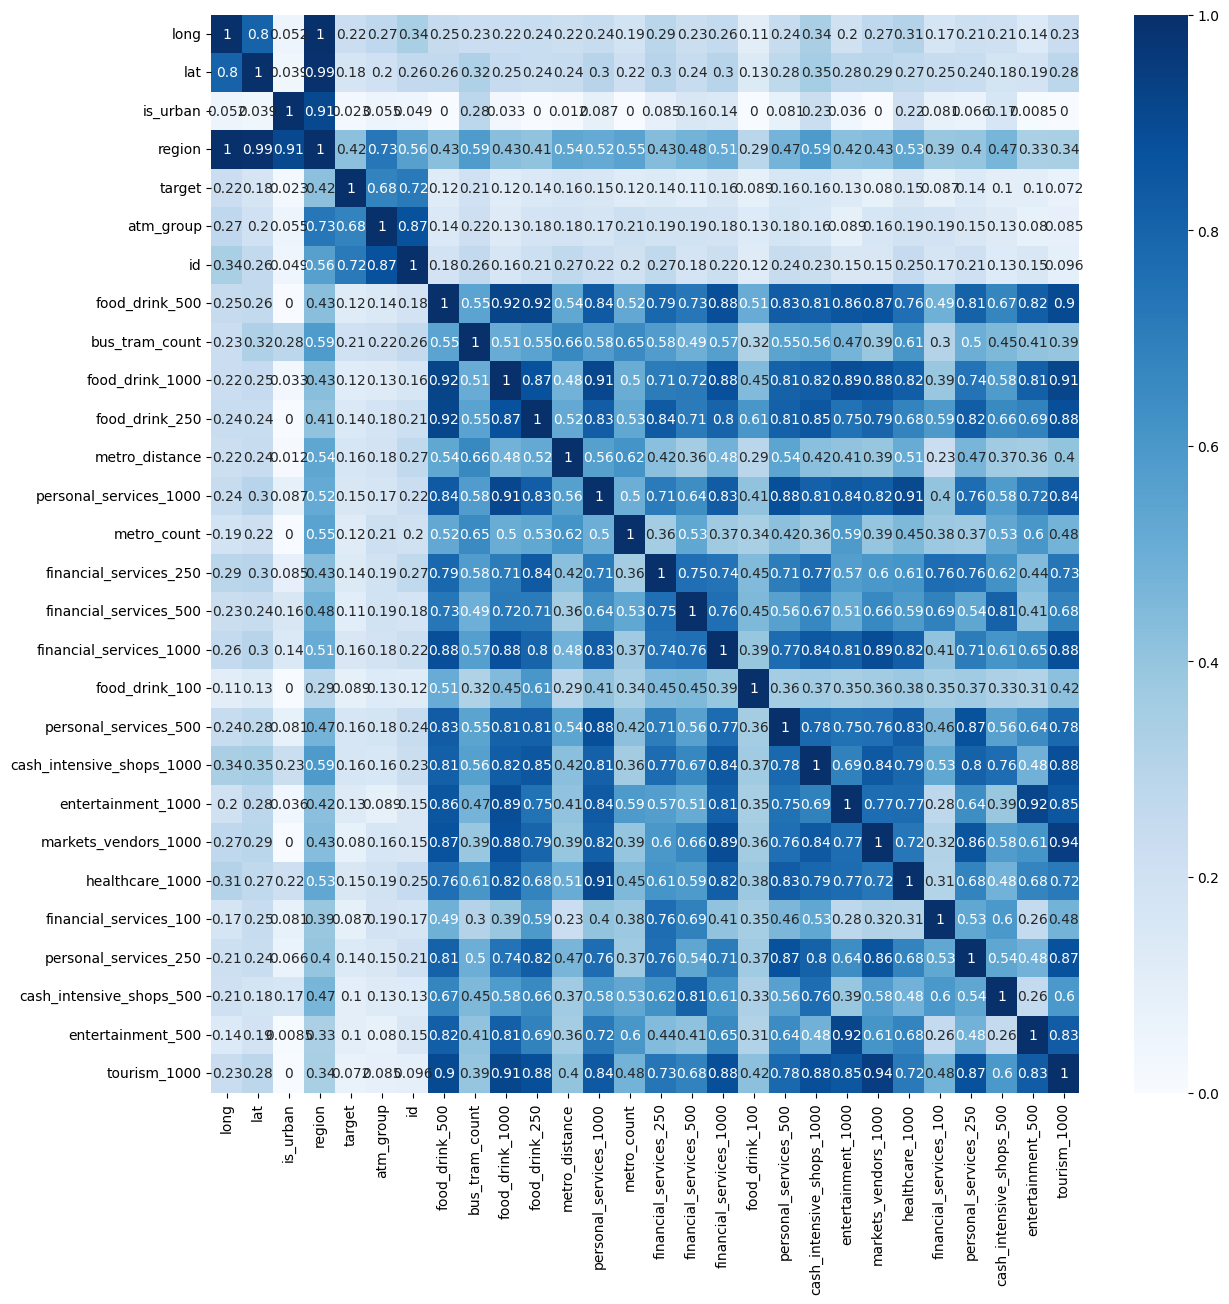

In [34]:
plt.figure(figsize=(14,14))

ph = df.phik_matrix()

sns.heatmap(ph, cmap="Blues", annot=True)

**Выводы**:
- Числовые признаки показали еще большую корреляцию, чем в случае метода Спирмана;
- Категориальный признак `region` показывает хорошую корреляцию с целевой переменной - его наличие в датасете оправдано;
- Признак `is_urban` имеет крайне низкую корреляцию с `target` - его можно удалить.

In [9]:
df = df.drop(columns=["is_urban"])

Посмотрим на `target` vs вещественные признаки:

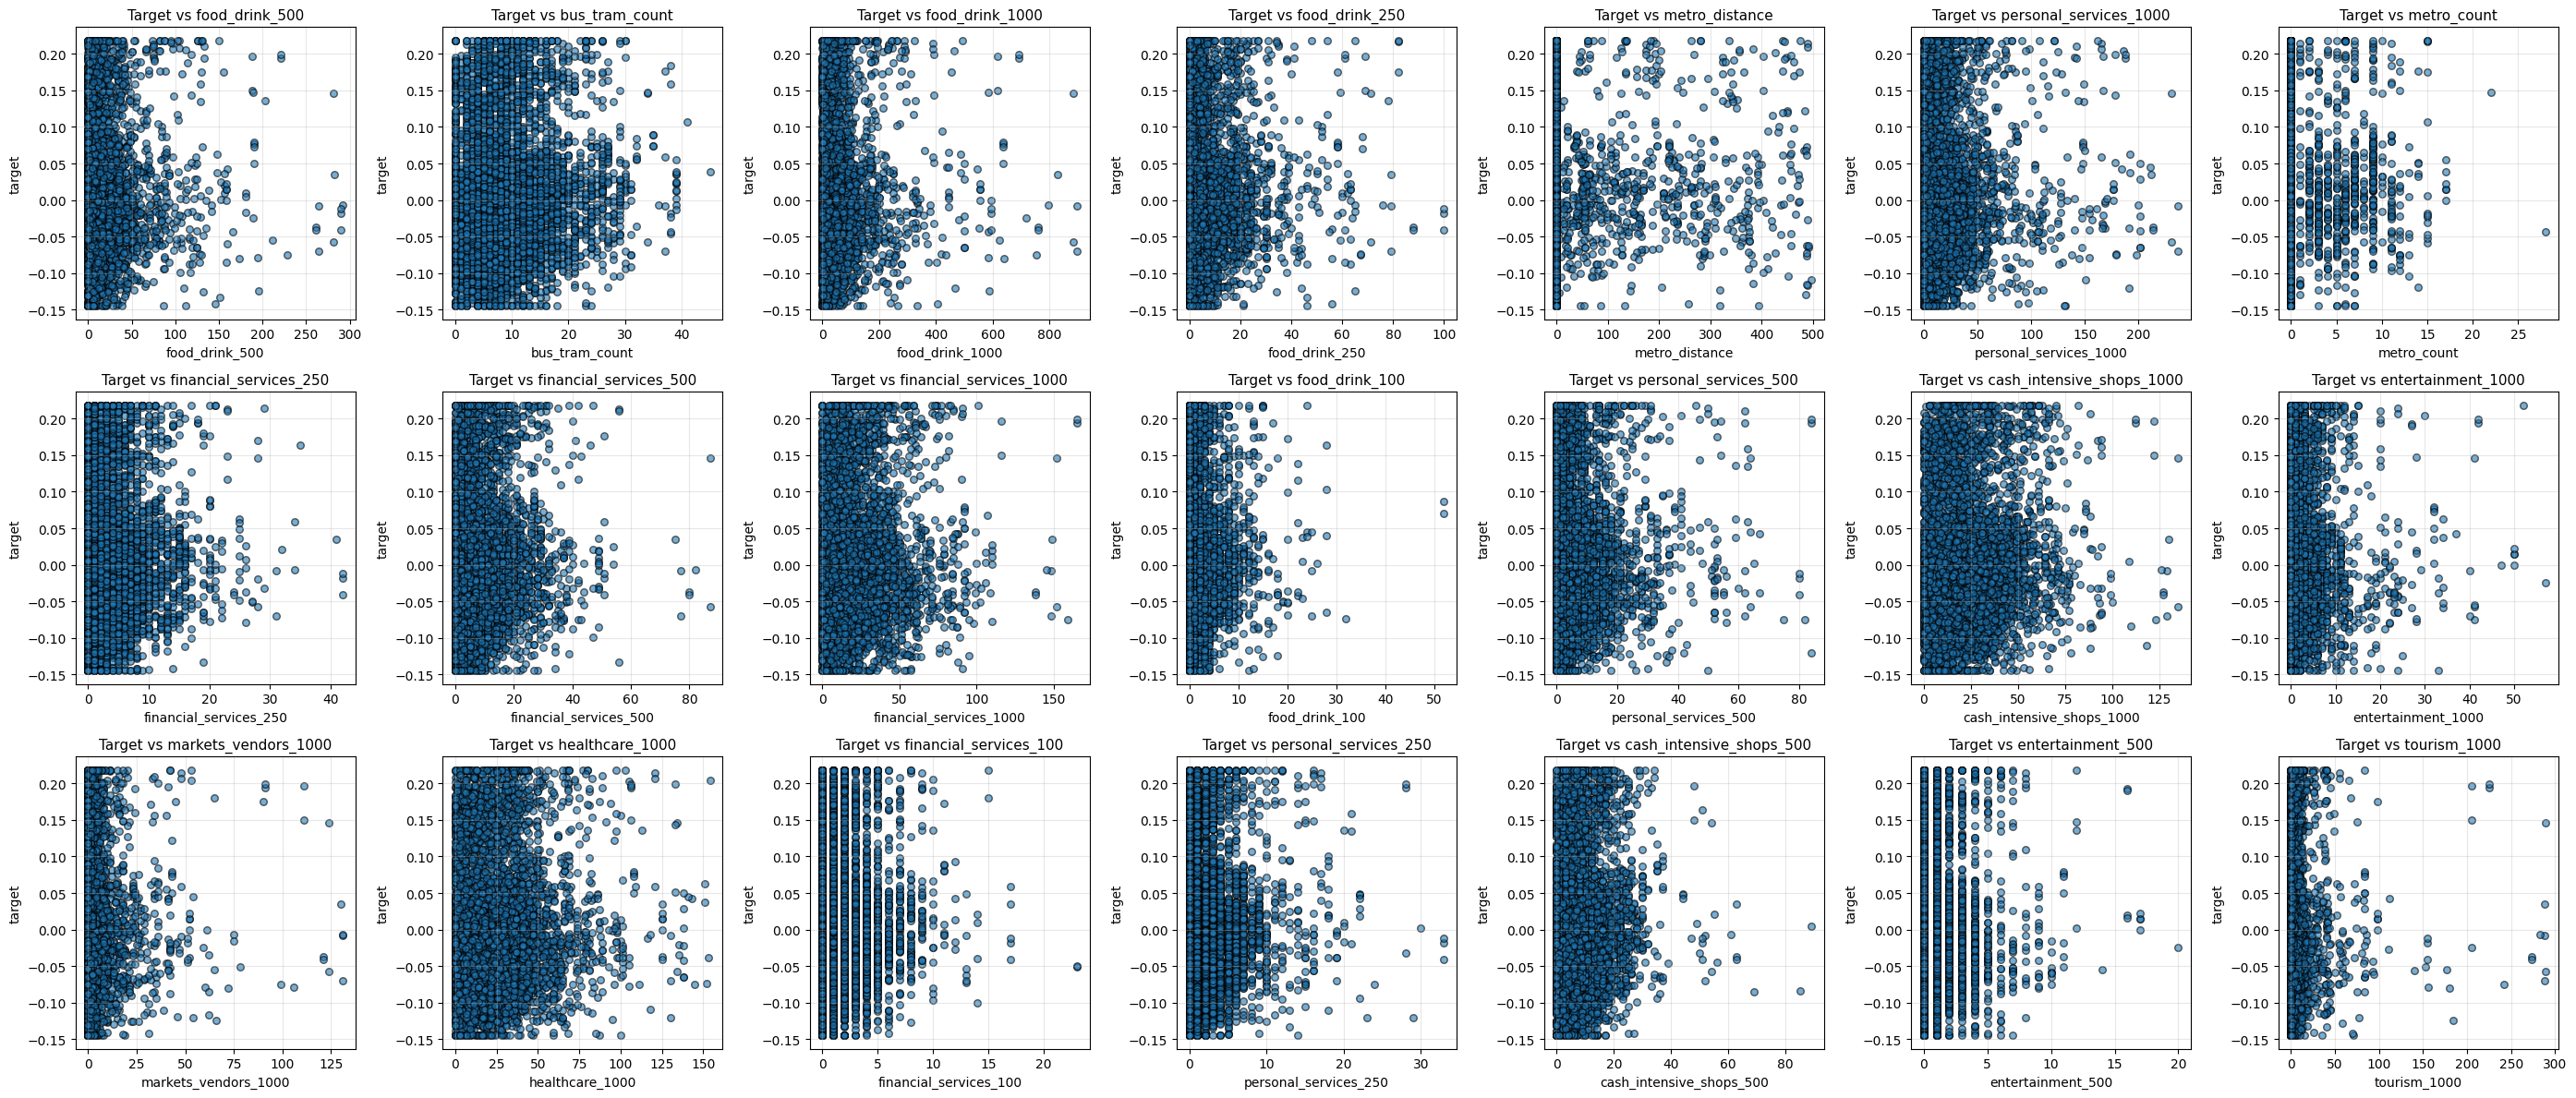

In [ ]:
fig, axes = plt.subplots(3, 7, figsize=(28, 12))
axes = axes.flatten()
features_to_plot = [col for col in df.columns if col != 'target'][6:27]

for idx, feature in enumerate(features_to_plot):
    if feature == "region": 
        continue
    axes[idx].scatter(df[feature], df['target'], alpha=0.6, edgecolors='k', s=30)
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('target', fontsize=10)
    axes[idx].set_title(f'Target vs {feature}', fontsize=11)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы**:
- Заметен большой разрос в значениях `target` при одинаковом значении признаков (особенно около 0);
- Зависимость с целевой переменной наиболее заметна у признаков `metro_distance` и `bus_tram_count`.

In [10]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)

print(f"Total samples: {len(df)}")
print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

train_df.to_csv("dataset/atm_train_split.csv", index=False, encoding='utf-8')
test_df.to_csv("dataset/atm_test_split.csv", index=False, encoding='utf-8')

Total samples: 6083
Train samples: 4866
Test samples: 1217


In [11]:
train_df.describe()

,long,lat,target,atm_group,id,food_drink_500,bus_tram_count,food_drink_1000,food_drink_250,metro_distance,...,personal_services_500,cash_intensive_shops_1000,entertainment_1000,markets_vendors_1000,healthcare_1000,financial_services_100,personal_services_250,cash_intensive_shops_500,entertainment_500,tourism_1000
count,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,...,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000,4866.000000
mean,63.277491,54.170802,-0.000096,4406.627209,4457.130908,15.752569,8.765516,43.248048,5.994451,21.643859,...,5.750103,21.314016,2.330045,3.678586,23.597205,1.490958,1.866626,7.687834,0.797986,5.465475
std,32.797527,4.309590,0.085573,2426.233505,2554.606346,26.450544,6.605013,76.498677,9.761902,75.670466,...,9.094707,17.719965,4.508390,8.721915,21.390475,2.079415,3.184380,7.390069,1.607563,16.521640
min,19.941530,42.057080,-0.145001,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.845066,52.249110,-0.061457,1942.000000,2243.250000,2.000000,4.000000,7.000000,1.000000,0.000000,...,0.000000,8.000000,0.000000,0.000000,8.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,48.500240,55.069638,-0.016066,5478.000000,4455.500000,7.000000,7.000000,20.000000,3.000000,0.000000,...,2.000000,17.000000,1.000000,1.000000,19.000000,1.000000,1.000000,6.000000,0.000000,2.000000
75%,84.945715,56.121133,0.039029,5478.000000,6721.750000,18.000000,12.000000,47.000000,7.000000,0.000000,...,7.000000,30.000000,3.000000,3.000000,33.000000,2.000000,2.000000,11.000000,1.000000,5.000000
max,173.706490,69.491912,0.218608,8083.000000,8811.000000,292.000000,45.000000,897.000000,100.000000,496.429163,...,84.000000,135.000000,52.000000,131.000000,154.000000,23.000000,33.000000,89.000000,17.000000,289.000000


In [12]:
test_df.describe()

,long,lat,target,atm_group,id,food_drink_500,bus_tram_count,food_drink_1000,food_drink_250,metro_distance,...,personal_services_500,cash_intensive_shops_1000,entertainment_1000,markets_vendors_1000,healthcare_1000,financial_services_100,personal_services_250,cash_intensive_shops_500,entertainment_500,tourism_1000
count,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,...,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000,1217.000000
mean,62.952668,54.218787,0.003855,4451.224322,4321.251027,15.782251,8.817584,43.163517,6.112572,19.585934,...,5.684470,20.928513,2.236647,3.819228,23.834840,1.524240,1.949055,7.446179,0.800329,5.559573
std,33.298194,4.429476,0.087474,2466.677633,2521.969885,26.161337,6.526483,74.555858,9.631004,73.277324,...,8.622799,17.646072,4.185840,9.590044,20.293079,2.155076,3.250865,7.358575,1.532670,17.730343
min,20.442161,42.809064,-0.145001,32.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37.668695,52.329683,-0.059632,1942.000000,2209.000000,3.000000,4.000000,9.000000,1.000000,0.000000,...,0.000000,8.000000,0.000000,0.000000,8.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,48.046025,55.161615,-0.012684,5478.000000,4274.000000,8.000000,8.000000,21.000000,3.000000,0.000000,...,3.000000,17.000000,1.000000,1.000000,20.000000,1.000000,1.000000,5.000000,0.000000,2.000000
75%,84.947155,56.129780,0.042189,5478.000000,6404.000000,17.000000,12.000000,48.000000,7.000000,0.000000,...,7.000000,29.000000,3.000000,3.000000,34.000000,2.000000,2.000000,10.000000,1.000000,5.000000
max,158.737224,69.490557,0.218608,8083.000000,8797.000000,290.000000,39.000000,885.000000,100.000000,491.680048,...,80.000000,135.000000,57.000000,130.000000,151.000000,17.000000,33.000000,63.000000,20.000000,289.000000


Распределение целевой переменной почти одинаковое для тренировочной и тестовой выборок.

## Метрика качества

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
def target_score(y_pred, y_true) -> float:
    mse = mean_squared_error(y_true, y_pred)
    return np.sqrt(mse)

In [9]:
def test_performance(y_true, y_pred):
    test_rmse = target_score(y_true, y_pred)
    test_mae = mean_absolute_error(y_true, y_pred)
    test_r2 = r2_score(y_true, y_pred)
    
    print(f"\nTest Performance:")
    print(f"   RMSE: {test_rmse:.4f}")
    print(f"   MAE:  {test_mae:.4f}")
    print(f"   R²:   {test_r2:.3f}")

## KNN

### Импорты библиотек

In [14]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### Подготовка датасета для KNN

In [15]:
df_knn_train = pd.read_csv("dataset/atm_train_split.csv", encoding='utf-8')
df_knn_test = pd.read_csv("dataset/atm_test_split.csv", encoding='utf-8')

Датасет содержит категориальный `region`. Для него требуется применить one-hot encoding.

In [16]:
# Сопоставим русским названиям регионов - id

unique_regions_train = df_knn_train['region'].unique()
unique_regions_test = df_knn_test['region'].unique()
all_unique_regions = list(set(unique_regions_train) | set(unique_regions_test))
region_to_id = {region: idx for idx, region in enumerate(sorted(all_unique_regions))}

df_knn_train['region'] = df_knn_train['region'].map(region_to_id)
df_knn_test['region'] = df_knn_test['region'].map(region_to_id)

In [17]:
df_knn_train = pd.get_dummies(df_knn_train, columns=['region'], prefix='region', drop_first=False)
df_knn_test = pd.get_dummies(df_knn_test, columns=['region'], prefix='region', drop_first=False)

# Убедимся, что в test и train одинаковое количество колонок
train_cols = set(df_knn_train.columns)
test_cols = set(df_knn_test.columns)
missing_in_test = train_cols - test_cols
missing_in_train = test_cols - train_cols

for col in missing_in_test:
    df_knn_test[col] = 0
for col in missing_in_train:
    df_knn_train[col] = 0

df_knn_test = df_knn_test[df_knn_train.columns]

print(f"\nTrain set head:")
print(df_knn_train.head())


Train set head:
        long        lat    target  atm_group      id  food_drink_500  \
0  38.122524  50.178381 -0.062759     5478.0  5909.0               2   
1  48.333054  54.263818 -0.037463     5478.0  6206.0               6   
2  39.274138  51.642933 -0.025334     5478.0  8165.0               0   
3  37.731838  55.815701  0.030580     5478.0  6530.0              10   
4  45.959741  51.503074 -0.095105     5478.0  6883.0               1   

   bus_tram_count  food_drink_1000  food_drink_250  metro_distance  ...  \
0               2                2               1        0.000000  ...   
1              13               18               3        0.000000  ...   
2               0                9               0        0.000000  ...   
3              22               20               7       75.309055  ...   
4               6                7               1        0.000000  ...   

   region_71  region_72  region_73  region_74  region_75  region_76  \
0      False      False     

### Применим KNN

In [18]:
X_knn_train = df_knn_train.drop(columns=['target'])
y_knn_train = df_knn_train['target']
X_knn_test = df_knn_test.drop(columns=['target'])
y_knn_test = df_knn_test['target']

Подбор гиперпараметров:
- n_neighbors - количество соседей;
- weights - веса соседей (`uniform`: Все соседи равнозначны, `distance`: Близкие соседи важнее);
- p - метрика расстояния (`1`: Манхэттенское расстояние, `2`: Евклидово расстояние).

In [6]:
def optimize_knn(X_train, y_train, X_test, y_test):
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor())
    ])
    
    param_grid = {
        'knn__n_neighbors': [3, 5, 7, 10, 15, 20, 25, 30],
        'knn__weights': ['uniform', 'distance'],
        'knn__p': [1, 2]
    }
    
    grid_search = GridSearchCV(
        knn_pipeline,
        param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_params = grid_search.best_params_
    best_score = -grid_search.best_score_
    
    print(f"\nBest Parameters: {best_params}")
    print(f"Best CV RMSE: {best_score:.4f}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    test_performance(y_test, y_pred)

    return grid_search

In [20]:
optimize_knn(X_knn_train, y_knn_train, X_knn_test, y_knn_test)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Parameters: {'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV RMSE: 0.0630

Test Performance:
   RMSE: 0.0622
   MAE:  0.0455
   R²:   0.495

Best Parameters: {'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV RMSE: 0.0630

Test Performance:
   RMSE: 0.0622
   MAE:  0.0455
   R²:   0.495


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [1, 2], 'knn__weights': ['uniform', 'distance']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Лучшая KNN модель:
- n_neighbors = 7;
- weights = distance;
- p = 2.

Результаты:
- RMSE = 0.0622
- MAE = 0.0455
- R² = 0.495

## Линейные модели

### Импорты библиотек

In [23]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

### Подготовка данных

In [3]:
df_train = pd.read_csv("dataset/atm_train_split.csv", encoding='utf-8')
df_test = pd.read_csv("dataset/atm_test_split.csv", encoding='utf-8')

Категориальный признак `region` содержит 80+ регионов России. В случае линейных моделей лучше применить target-encoding, чем one-hot, чтобы сильно не увеличивать количество фичей.

In [4]:
overall_mean = df_train['target'].mean() # если в train не будет региона из test
region_target_mapping = df_train.groupby('region')['target'].mean()

df_train['region'] = df_train['region'].map(region_target_mapping)
df_test['region'] = df_test['region'].map(lambda x: region_target_mapping.get(x, overall_mean))

print(df_train.head())

        long        lat    region    target  atm_group      id  \
0  38.122524  50.178381 -0.056902 -0.062759     5478.0  5909.0   
1  48.333054  54.263818 -0.047466 -0.037463     5478.0  6206.0   
2  39.274138  51.642933 -0.015593 -0.025334     5478.0  8165.0   
3  37.731838  55.815701  0.038968  0.030580     5478.0  6530.0   
4  45.959741  51.503074 -0.010633 -0.095105     5478.0  6883.0   

   food_drink_500  bus_tram_count  food_drink_1000  food_drink_250  ...  \
0               2               2                2               1  ...   
1               6              13               18               3  ...   
2               0               0                9               0  ...   
3              10              22               20               7  ...   
4               1               6                7               1  ...   

   personal_services_500  cash_intensive_shops_1000  entertainment_1000  \
0                      0                          3                   0   
1 

In [5]:
X_train = df_train.drop(columns=['target'])
y_train = df_train['target']
X_test = df_test.drop(columns=['target'])
y_test = df_test['target']

### Простая линейная регрессия

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model.predict(X_test)
test_performance(y_test, y_pred)


Test Performance:
   RMSE: 0.0608
   MAE:  0.0484
   R²:   0.516


Результаты:
- RMSE = 0.0608
- MAE = 0.0484
- R² = 0.516

**Промежуточный вывод**: Линейная регрессия показала лучший результат, чем KNN

### Стандартизация и полиномиальные признаки

Сначала добавим Standart Scaler:

In [49]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('linear_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [51]:
y_pred = pipeline.predict(X_test)
test_performance(y_test, y_pred)


Test Performance:
   RMSE: 0.0608
   MAE:  0.0484
   R²:   0.516


Метрики не изменились

Добавим полиномиальные признаки:

In [59]:
pipeline_2 = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear_regression', LinearRegression())
])

pipeline_2.fit(X_train, y_train)

,steps,"[('poly_features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [60]:
y_pred = pipeline_2.predict(X_test)
test_performance(y_test, y_pred)


Test Performance:
   RMSE: 0.0501
   MAE:  0.0390
   R²:   0.672


Результаты:
- RMSE = 0.0501
- MAE = 0.0390
- R² = 0.672

**Промежуточный вывод**: Модель с полиномиальными признаками показала лучший результат, чем предыдущие.

### Регуляризации, кросс-валидация и GridSearch

In [ ]:
def optimize_lr(X_train, y_train, X_test, y_test):

    base_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', Ridge())  # placeholder
    ])
    
    param_grids = {
        'ridge': {
            'model': [Ridge()],
            'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
        },
        'lasso': {
            'model': [Lasso(max_iter=10000)],
            'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
        },
        'elastic': {
            'model': [ElasticNet(max_iter=10000)],
            'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
            'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        }
    }
    
    results = {}
    
    for model_name, param_grid in param_grids.items():
        print(f"\n{'='*60}")
        print(f"Tuning {model_name.upper()} with 5-fold CV...")
        print('='*60)
        
        grid_search = GridSearchCV(
            base_pipeline,
            param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=1
        )
        
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        cv_rmse = -grid_search.best_score_
        
        results[model_name] = {
            'model': best_model,
            'cv_rmse': cv_rmse,
            'best_params': grid_search.best_params_,
            'grid_search': grid_search
        }
        
        print(f"Best CV RMSE: {cv_rmse:.4f}")
        print(f"Best params: {grid_search.best_params_}")
        
        y_pred = best_model.predict(X_test)
        test_performance(y_test, y_pred)
    
    return results

In [14]:
result = optimize_lr(X_train, y_train, X_test, y_test)


Tuning RIDGE with 5-fold CV...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best CV RMSE: 0.0504
Best params: {'model': Ridge(), 'model__alpha': 10.0}

Test Performance:
   RMSE: 0.0479
   MAE:  0.0379
   R²:   0.699

Tuning LASSO with 5-fold CV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best CV RMSE: 0.0494
Best params: {'model': Lasso(max_iter=10000), 'model__alpha': 0.0001}

Test Performance:
   RMSE: 0.0471
   MAE:  0.0375
   R²:   0.710

Tuning ELASTIC with 5-fold CV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV RMSE: 0.0492
Best params: {'model': ElasticNet(max_iter=10000), 'model__alpha': 0.001, 'model__l1_ratio': 0.3}

Test Performance:
   RMSE: 0.0477
   MAE:  0.0381
   R²:   0.703


Результаты:

Ridge, $\alpha =  10.0$:
- RMSE = 0.0479
- MAE = 0.0379
- R² = 0.699

Lasso, $\alpha =  0.0001$:
- RMSE = 0.0471
- MAE = 0.0375
- R² = 0.710

ElasticNet, $\alpha =  0.001$, $l_1 ratio = 0.3$:
- RMSE = 0.0477
- MAE = 0.0381
- R² = 0.703

**Вывод**:
Наилучший результат показала модель c $L_1$ регуляризацией, где $\alpha = 0.0001$



### Сохранение лучшей модели

In [17]:
best_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.0001, max_iter=10000))
])
best_pipeline.fit(X_train, y_train)

with open("models/best_linear_model.pkl", 'wb') as f:
    pickle.dump(best_pipeline, f)

### Анализ весов

Загрузим лучшую модель:

In [ ]:
with open('models/best_linear_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

In [ ]:
def analyze_lasso_coefficients(model, original_features_df):
    lasso_model = model.named_steps['model']
    poly = model.named_steps['poly']
    original_features = original_features_df.columns.tolist()
    poly_feature_names = poly.get_feature_names_out(original_features)
    coefficients = lasso_model.coef_
    coef_df = pd.DataFrame({
        'feature': poly_feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients),
        'is_nonzero': coefficients != 0
    })
    coef_df = coef_df.sort_values('abs_coefficient', ascending=False)
    return coef_df

coef_df = analyze_lasso_coefficients(best_model, X_train)

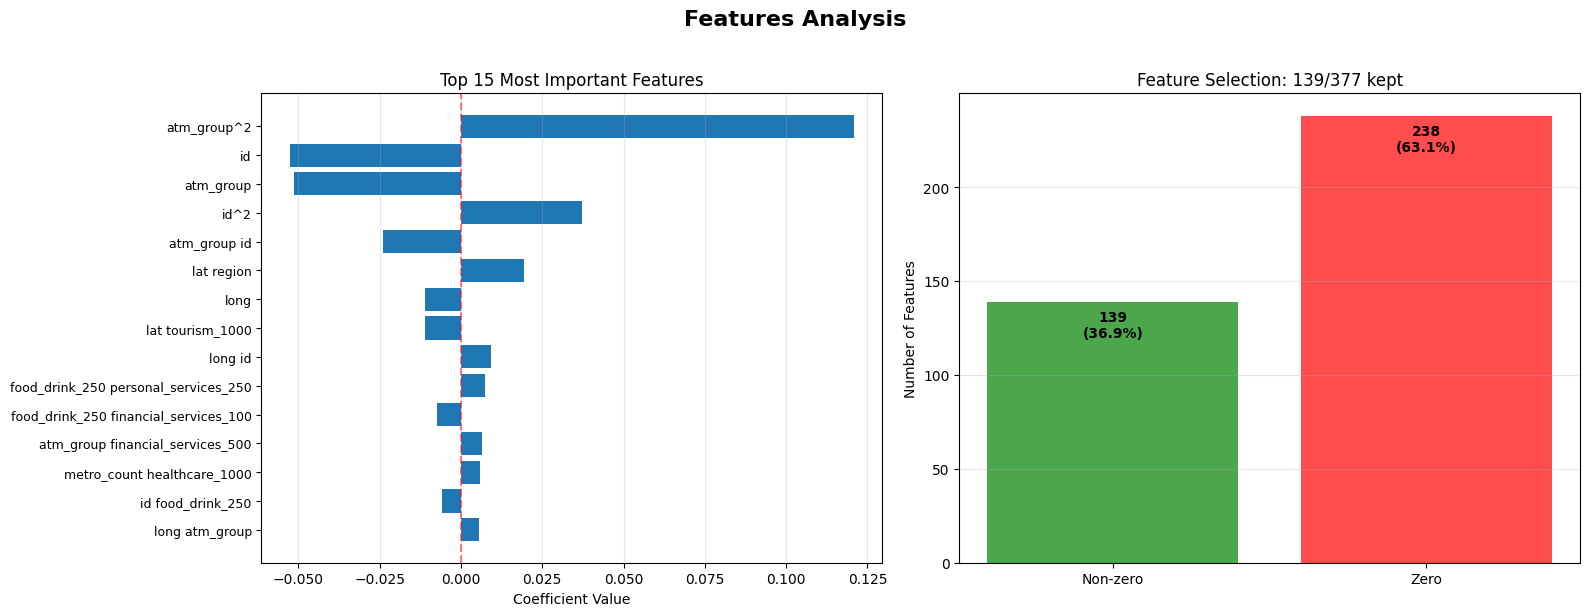

In [50]:
def plot_lasso_coefficients(coef_df, top_n):
    _, axes = plt.subplots(1, 2, figsize=(16, 6))
    top_features = coef_df.head(top_n)
    
    axes[0].barh(range(len(top_features)), top_features['coefficient'].values)
    axes[0].set_yticks(range(len(top_features)))
    axes[0].set_yticklabels(top_features['feature'].values, fontsize=9)
    axes[0].invert_yaxis()
    axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Coefficient Value')
    axes[0].set_title(f'Top {top_n} Most Important Features')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    nonzero_count = np.sum(coef_df['is_nonzero'])
    zero_count = len(coef_df) - nonzero_count
    
    axes[1].bar(['Non-zero', 'Zero'], [nonzero_count, zero_count], 
                   color=['green', 'red'], alpha=0.7)
    axes[1].set_ylabel('Number of Features')
    axes[1].set_title(f'Feature Selection: {nonzero_count}/{len(coef_df)} kept')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate([nonzero_count, zero_count]):
        axes[1].text(i, v - 0.08*max(nonzero_count, zero_count), 
                       f'{v}\n({v/len(coef_df)*100:.1f}%)', 
                       ha='center', fontweight='bold')
    
    plt.suptitle(f'Features Analysis', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_lasso_coefficients(coef_df, top_n=15)

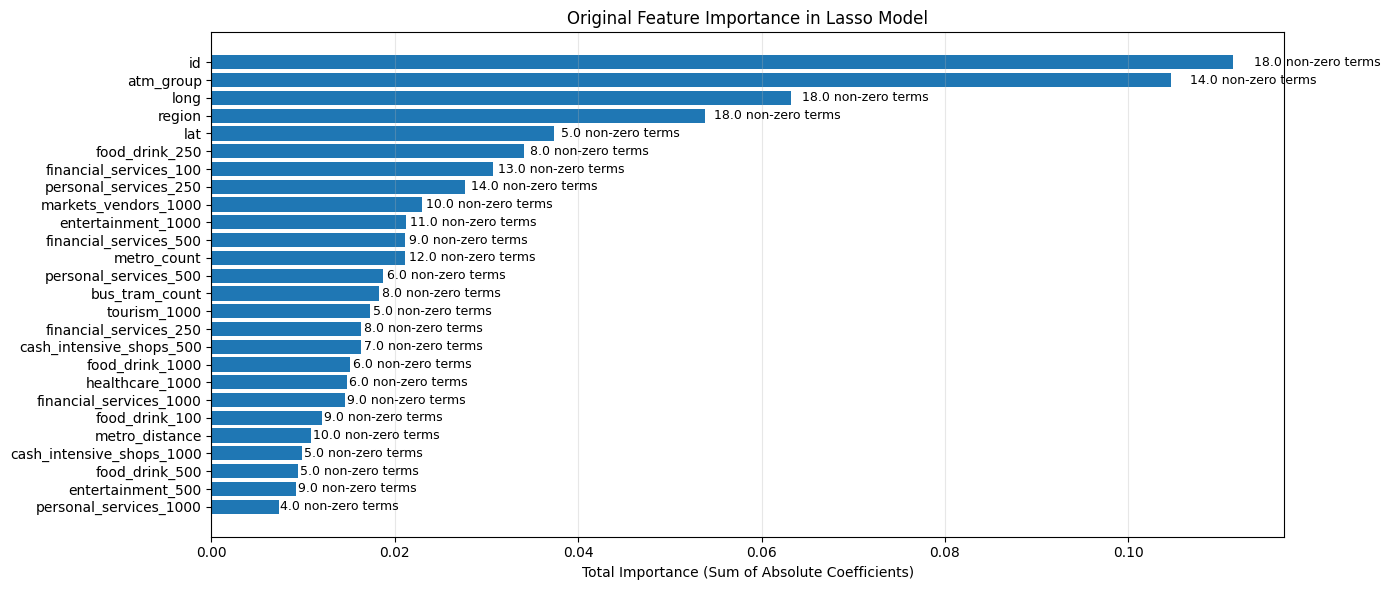

In [56]:
def plot_feature_importance(coef_df, original_features_df):
    importance_dict = {}
    original_features = original_features_df.columns.tolist()
    for orig_feat in original_features:
        mask = coef_df['feature'].str.contains(f'^{orig_feat}(?= |$)| {orig_feat}(?= |$)')
        related_coefs = coef_df[mask]
        if len(related_coefs) > 0:
            total_importance = related_coefs['abs_coefficient'].sum()
            importance_dict[orig_feat] = {
                'total_importance': total_importance,
                'non_zero_terms': related_coefs['is_nonzero'].sum()
            }
    importance_df = pd.DataFrame(importance_dict).T
    importance_df = importance_df.sort_values('total_importance', ascending=False)
    _, ax = plt.subplots(figsize=(14, 6))
    _ = ax.barh(range(len(importance_df)), importance_df['total_importance'].values)
    ax.set_yticks(range(len(importance_df)))
    ax.set_yticklabels(importance_df.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Total Importance (Sum of Absolute Coefficients)')
    ax.set_title('Original Feature Importance in Lasso Model')
    ax.grid(True, alpha=0.3, axis='x')
    for i, (_, row) in enumerate(importance_df.iterrows()):
        ax.text(row['total_importance'] * 1.02, i, 
               f"{row['non_zero_terms']} non-zero terms", 
               va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


importance_df = plot_feature_importance(coef_df, X_train)

**Выводы**:
- Наиболее значимые признаки: `id`, `atm_group` и `region`;
- Большинство признаков, связанных с окружающими строениями, окакзались незначимы для Lasso регрессии.

## Выводы

1) В результате дополнительного EDA было выявлено, что многие признаки не обладают приемлимой корреляцией с целевой переменной, вследсвие чего данные признаки были удалены. Для оставшихся признаков можно заметить не строго линейную зависимость, что подтверждается большим коэффициентом корреляции Спирмана, чем Пирсона для одних и тех же фичей.
2) Основная метрика оценки - RMSE.
3) Для KNN модели был применен one-hot encoding фичи `region`, а также подбор гиперпараметров через GridSearch. Тем не менее KNN, как простейший из методов, показал наихудший результат: RMSE = 0.0622.
4) Для линейной модели были применены target encoding `region`, стандартизация и регуляризация с подбором параметров через GridSearch. Данный подход показал наилучший результат, где модель с $L_1$ регуляризацией показала RMSE = 0.0471.
5) В ходе анализа весов лучшей модели было найдено, что наиболее важными признаками являются `id`, `atm_group` и `region`. Также большое значение имели произведения признаков, основанных на близости определенных типов объекта к банкомату.